<a href="https://colab.research.google.com/github/M7office/Stroke/blob/main/Longitudinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Time-dependent biomarker screen
# One adjusted regression model per protein
# Outcome: protein NPX
# Main predictor: log time since stroke
# Covariates: age, sex, NIHSS, stroke size
# ============================================================

import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 0. Load data
# ------------------------------------------------------------

def find_file(filename):
    for root, dirs, files in os.walk("."):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename}")

clinical = pd.read_csv(find_file("Subject_Clinical_Data.csv"))
npx = pd.read_csv(find_file("C_NPX_data.csv"))

protein_cols_all = [c for c in npx.columns if c != "PID"]

data_time = clinical[
    ["PID", "Time Since Stroke", "Age", "Sex", "NIHSS", "Stroke Size"]
].merge(
    npx[["PID"] + protein_cols_all],
    on="PID",
    how="inner"
)

print("Data shape:", data_time.shape)
print("Proteins:", len(protein_cols_all))

# ------------------------------------------------------------
# 1. Prepare covariates
# ------------------------------------------------------------

data_time["time_since_stroke"] = pd.to_numeric(
    data_time["Time Since Stroke"], errors="coerce"
)

data_time["age"] = pd.to_numeric(data_time["Age"], errors="coerce")
data_time["sex"] = pd.to_numeric(data_time["Sex"], errors="coerce")
data_time["nihss"] = pd.to_numeric(data_time["NIHSS"], errors="coerce")
data_time["stroke_size"] = pd.to_numeric(data_time["Stroke Size"], errors="coerce")

# Log-transform time because time since stroke is usually skewed
data_time["log_time"] = np.log1p(data_time["time_since_stroke"])

# Optional: standardize continuous predictors for easier interpretation
for col in ["log_time", "age", "nihss", "stroke_size"]:
    data_time[col + "_z"] = (
        data_time[col] - data_time[col].mean()
    ) / data_time[col].std(ddof=0)

# ------------------------------------------------------------
# 2. Run one adjusted model per protein
# ------------------------------------------------------------

rows = []

for protein in protein_cols_all:
    tmp = data_time[
        [
            protein,
            "log_time_z",
            "age_z",
            "sex",
            "nihss_z",
            "stroke_size_z"
        ]
    ].copy()

    tmp[protein] = pd.to_numeric(tmp[protein], errors="coerce")
    tmp = tmp.dropna()

    if tmp.shape[0] < 20:
        continue

    y = tmp[protein]

    X = tmp[
        [
            "log_time_z",
            "age_z",
            "sex",
            "nihss_z",
            "stroke_size_z"
        ]
    ]

    X = sm.add_constant(X)

    fit = sm.OLS(y, X).fit()

    rows.append({
        "protein": protein,
        "n": tmp.shape[0],
        "time_beta": fit.params["log_time_z"],
        "time_p": fit.pvalues["log_time_z"],
        "age_beta": fit.params["age_z"],
        "age_p": fit.pvalues["age_z"],
        "sex_beta": fit.params["sex"],
        "sex_p": fit.pvalues["sex"],
        "nihss_beta": fit.params["nihss_z"],
        "nihss_p": fit.pvalues["nihss_z"],
        "stroke_size_beta": fit.params["stroke_size_z"],
        "stroke_size_p": fit.pvalues["stroke_size_z"],
        "model_r2": fit.rsquared,
        "model_adj_r2": fit.rsquared_adj
    })

time_screen_results = pd.DataFrame(rows)

# ------------------------------------------------------------
# 3. Multiple-testing correction
# ------------------------------------------------------------

time_screen_results["time_FDR_q"] = multipletests(
    time_screen_results["time_p"],
    method="fdr_bh"
)[1]

time_screen_results["direction"] = np.where(
    time_screen_results["time_beta"] > 0,
    "higher_later_after_stroke",
    "lower_later_after_stroke"
)

time_screen_results = time_screen_results.sort_values("time_p")

display(time_screen_results.head(30))

print("Nominal time-dependent proteins p < 0.05:",
      (time_screen_results["time_p"] < 0.05).sum())

print("FDR-significant time-dependent proteins q < 0.05:",
      (time_screen_results["time_FDR_q"] < 0.05).sum())

time_screen_results.to_csv(
    "strokecog_time_dependent_biomarker_screen_adjusted.csv",
    index=False
)

Data shape: (85, 1202)
Proteins: 1196


,protein,n,time_beta,time_p,age_beta,age_p,sex_beta,sex_p,nihss_beta,nihss_p,stroke_size_beta,stroke_size_p,model_r2,model_adj_r2,time_FDR_q,direction
507,OID00983,63,0.539863,0.000397,0.069540,0.595415,-0.261167,0.349871,0.098976,0.558456,0.104009,0.533083,0.245775,0.179615,0.144827,higher_later_after_stroke
687,OID01163,63,0.484248,0.000597,-0.003948,0.974074,-0.201324,0.437267,0.210321,0.183424,0.014289,0.926417,0.238928,0.172167,0.144827,higher_later_after_stroke
393,OID01425,63,0.217100,0.000785,0.043206,0.439985,-0.210731,0.079970,0.029888,0.678534,0.029577,0.677525,0.234888,0.167773,0.144827,higher_later_after_stroke
678,OID01154,63,0.475307,0.000818,0.069065,0.573867,-0.346373,0.187757,0.166147,0.296437,0.109054,0.485985,0.254338,0.188930,0.144827,higher_later_after_stroke
729,OID01205,63,0.269236,0.000935,0.043721,0.534853,-0.177403,0.238676,0.088995,0.329133,-0.026925,0.763806,0.203897,0.134063,0.144827,higher_later_after_stroke
535,OID01011,63,0.741564,0.000954,0.160506,0.409610,-0.518131,0.212685,0.191684,0.445495,0.147132,0.552271,0.233587,0.166358,0.144827,higher_later_after_stroke
33,OID01243,62,0.517858,0.001146,0.101318,0.448734,0.865759,0.003362,0.167065,0.334837,-0.240206,0.160157,0.277132,0.212590,0.144827,higher_later_after_stroke
1052,OID05442,63,0.365326,0.001281,0.011206,0.909279,-0.302741,0.151611,-0.033557,0.791626,0.181800,0.150315,0.249586,0.183760,0.144827,higher_later_after_stroke
1053,OID05443,63,0.427364,0.001591,0.042010,0.720897,-0.315883,0.209656,0.084266,0.579219,0.083640,0.576813,0.211202,0.142009,0.144827,higher_later_after_stroke
726,OID01202,63,0.328110,0.001615,-0.014234,0.874857,-0.238953,0.217054,0.128484,0.273420,0.099069,0.390900,0.253149,0.187636,0.144827,higher_later_after_stroke


Nominal time-dependent proteins p < 0.05: 152
FDR-significant time-dependent proteins q < 0.05: 0


In [ ]:
# ============================================================
# Add direction and FDR correction for all predictors
# ============================================================

from statsmodels.stats.multitest import multipletests
import numpy as np

predictors = {
    "time": {
        "beta": "time_beta",
        "p": "time_p",
        "positive": "higher_later_after_stroke",
        "negative": "lower_later_after_stroke"
    },
    "age": {
        "beta": "age_beta",
        "p": "age_p",
        "positive": "higher_in_older_patients",
        "negative": "higher_in_younger_patients"
    },
    "sex": {
        "beta": "sex_beta",
        "p": "sex_p",
        "positive": "higher_when_sex_equals_1",
        "negative": "higher_when_sex_equals_0"
    },
    "nihss": {
        "beta": "nihss_beta",
        "p": "nihss_p",
        "positive": "higher_with_higher_NIHSS",
        "negative": "higher_with_lower_NIHSS"
    },
    "stroke_size": {
        "beta": "stroke_size_beta",
        "p": "stroke_size_p",
        "positive": "higher_with_larger_stroke_size",
        "negative": "higher_with_smaller_stroke_size"
    }
}

for name, info in predictors.items():
    beta_col = info["beta"]
    p_col = info["p"]

    # FDR correction for this predictor across all proteins
    q_col = f"{name}_FDR_q"
    direction_col = f"{name}_direction"

    time_screen_results[q_col] = multipletests(
        time_screen_results[p_col],
        method="fdr_bh"
    )[1]

    time_screen_results[direction_col] = np.where(
        time_screen_results[beta_col] > 0,
        info["positive"],
        info["negative"]
    )

display(time_screen_results.head(30))

time_screen_results.to_csv(
    "strokecog_adjusted_biomarker_screen_all_predictor_directions.csv",
    index=False
)

,protein,n,time_beta,time_p,age_beta,age_p,sex_beta,sex_p,nihss_beta,nihss_p,...,direction,time_direction,age_FDR_q,age_direction,sex_FDR_q,sex_direction,nihss_FDR_q,nihss_direction,stroke_size_FDR_q,stroke_size_direction
507,OID00983,63,0.539863,0.000397,0.069540,0.595415,-0.261167,0.349871,0.098976,0.558456,...,higher_later_after_stroke,higher_later_after_stroke,0.744892,higher_in_older_patients,0.732857,higher_when_sex_equals_0,0.911472,higher_with_higher_NIHSS,0.983162,higher_with_larger_stroke_size
687,OID01163,63,0.484248,0.000597,-0.003948,0.974074,-0.201324,0.437267,0.210321,0.183424,...,higher_later_after_stroke,higher_later_after_stroke,0.986824,higher_in_younger_patients,0.789207,higher_when_sex_equals_0,0.805391,higher_with_higher_NIHSS,0.990098,higher_with_larger_stroke_size
393,OID01425,63,0.217100,0.000785,0.043206,0.439985,-0.210731,0.079970,0.029888,0.678534,...,higher_later_after_stroke,higher_later_after_stroke,0.620549,higher_in_older_patients,0.452513,higher_when_sex_equals_0,0.931325,higher_with_higher_NIHSS,0.983162,higher_with_larger_stroke_size
678,OID01154,63,0.475307,0.000818,0.069065,0.573867,-0.346373,0.187757,0.166147,0.296437,...,higher_later_after_stroke,higher_later_after_stroke,0.727060,higher_in_older_patients,0.608829,higher_when_sex_equals_0,0.864037,higher_with_higher_NIHSS,0.983162,higher_with_larger_stroke_size
729,OID01205,63,0.269236,0.000935,0.043721,0.534853,-0.177403,0.238676,0.088995,0.329133,...,higher_later_after_stroke,higher_later_after_stroke,0.705275,higher_in_older_patients,0.656221,higher_when_sex_equals_0,0.871346,higher_with_higher_NIHSS,0.990098,higher_with_smaller_stroke_size
535,OID01011,63,0.741564,0.000954,0.160506,0.409610,-0.518131,0.212685,0.191684,0.445495,...,higher_later_after_stroke,higher_later_after_stroke,0.600368,higher_in_older_patients,0.632639,higher_when_sex_equals_0,0.885663,higher_with_higher_NIHSS,0.983162,higher_with_larger_stroke_size
33,OID01243,62,0.517858,0.001146,0.101318,0.448734,0.865759,0.003362,0.167065,0.334837,...,higher_later_after_stroke,higher_later_after_stroke,0.629913,higher_in_older_patients,0.103796,higher_when_sex_equals_1,0.871346,higher_with_higher_NIHSS,0.983162,higher_with_smaller_stroke_size
1052,OID05442,63,0.365326,0.001281,0.011206,0.909279,-0.302741,0.151611,-0.033557,0.791626,...,higher_later_after_stroke,higher_later_after_stroke,0.951441,higher_in_older_patients,0.562606,higher_when_sex_equals_0,0.952474,higher_with_lower_NIHSS,0.983162,higher_with_larger_stroke_size
1053,OID05443,63,0.427364,0.001591,0.042010,0.720897,-0.315883,0.209656,0.084266,0.579219,...,higher_later_after_stroke,higher_later_after_stroke,0.838709,higher_in_older_patients,0.631672,higher_when_sex_equals_0,0.919668,higher_with_higher_NIHSS,0.983162,higher_with_larger_stroke_size
726,OID01202,63,0.328110,0.001615,-0.014234,0.874857,-0.238953,0.217054,0.128484,0.273420,...,higher_later_after_stroke,higher_later_after_stroke,0.928349,higher_in_younger_patients,0.634177,higher_when_sex_equals_0,0.853813,higher_with_higher_NIHSS,0.983162,higher_with_larger_stroke_size


In [ ]:
# ============================================================
# Display directions for all predictors
# ============================================================

import numpy as np

time_screen_results["time_direction"] = np.where(
    time_screen_results["time_beta"] > 0,
    "higher_later_after_stroke",
    "lower_later_after_stroke"
)

time_screen_results["age_direction"] = np.where(
    time_screen_results["age_beta"] > 0,
    "higher_in_older_patients",
    "higher_in_younger_patients"
)

time_screen_results["sex_direction"] = np.where(
    time_screen_results["sex_beta"] > 0,
    "higher_in_male",
    "higher_in_female"
)

time_screen_results["nihss_direction"] = np.where(
    time_screen_results["nihss_beta"] > 0,
    "higher_with_higher_NIHSS",
    "higher_with_lower_NIHSS"
)

time_screen_results["stroke_size_direction"] = np.where(
    time_screen_results["stroke_size_beta"] > 0,
    "higher_with_larger_stroke_size",
    "higher_with_smaller_stroke_size"
)

direction_view = time_screen_results[
    [
        "protein",
         "time_p","time_direction",
          "age_direction",
         "sex_direction",
         "nihss_direction",
         "stroke_size_direction",
        "model_r2", "model_adj_r2"
    ]
].copy()


display(
    direction_view[direction_view["time_p"] < 0.05]
    .sort_values("time_p")
    .head(30)
)

,protein,time_p,time_direction,age_direction,sex_direction,nihss_direction,stroke_size_direction,model_r2,model_adj_r2
507,OID00983,0.000397,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.245775,0.179615
687,OID01163,0.000597,higher_later_after_stroke,higher_in_younger_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.238928,0.172167
393,OID01425,0.000785,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.234888,0.167773
678,OID01154,0.000818,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.254338,0.188930
729,OID01205,0.000935,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_smaller_stroke_size,0.203897,0.134063
535,OID01011,0.000954,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.233587,0.166358
33,OID01243,0.001146,higher_later_after_stroke,higher_in_older_patients,higher_in_male,higher_with_higher_NIHSS,higher_with_smaller_stroke_size,0.277132,0.212590
1052,OID05442,0.001281,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_lower_NIHSS,higher_with_larger_stroke_size,0.249586,0.183760
1053,OID05443,0.001591,higher_later_after_stroke,higher_in_older_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.211202,0.142009
726,OID01202,0.001615,higher_later_after_stroke,higher_in_younger_patients,higher_in_female,higher_with_higher_NIHSS,higher_with_larger_stroke_size,0.253149,0.187636


In [ ]:
# ============================================================
# Summary of nominal and FDR-significant proteins by predictor
# ============================================================

summary_rows = []

for name, info in predictors.items():
    beta_col = info["beta"]
    p_col = info["p"]
    q_col = f"{name}_FDR_q"
    direction_col = f"{name}_direction"

    nominal = time_screen_results[time_screen_results[p_col] < 0.05]
    fdr_sig = time_screen_results[time_screen_results[q_col] < 0.05]

    summary_rows.append({
        "predictor": name,
        "n_nominal_p05": nominal.shape[0],
        "n_FDR_q05": fdr_sig.shape[0],
        "n_positive_beta_nominal": (nominal[beta_col] > 0).sum(),
        "n_negative_beta_nominal": (nominal[beta_col] < 0).sum(),
        "median_abs_beta_nominal": nominal[beta_col].abs().median()
    })

predictor_summary = pd.DataFrame(summary_rows)

display(predictor_summary)

predictor_summary.to_csv(
    "strokecog_predictor_direction_summary.csv",
    index=False
)

,predictor,n_nominal_p05,n_FDR_q05,n_positive_beta_nominal,n_negative_beta_nominal,median_abs_beta_nominal
0,time,152,0,140,12,0.235904
1,age,443,298,431,12,0.169735
2,sex,157,16,45,112,0.319563
3,nihss,79,0,69,10,0.165079
4,stroke_size,32,1,10,22,0.167520


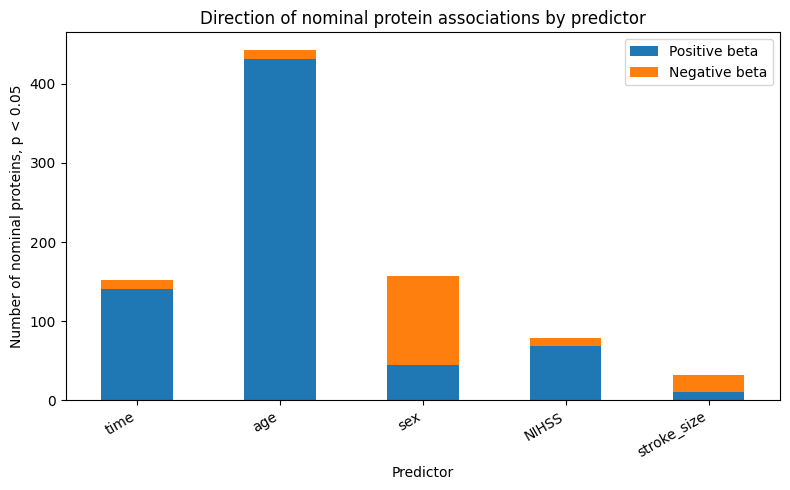

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Manually summarize from your table
direction_counts = pd.DataFrame({
    "predictor": [ "time","age", "sex","NIHSS", "stroke_size"],
    "positive_direction": [140, 431, 45, 69, 10],
    "negative_direction": [12, 12, 112, 10, 22]
})

direction_counts = direction_counts.set_index("predictor")

ax = direction_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.ylabel("Number of nominal proteins, p < 0.05")
plt.xlabel("Predictor")
plt.title("Direction of nominal protein associations by predictor")
plt.xticks(rotation=30, ha="right")
plt.legend(["Positive beta", "Negative beta"])
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# predictors and corresponding column names in your results table
predictor_map = {
    "time": ("time_beta", "time_p", "time_FDR_q"),
    "age": ("age_beta", "age_p", "age_FDR_q"),
    "sex": ("sex_beta", "sex_p", "sex_FDR_q"),
    "NIHSS": ("nihss_beta", "nihss_p", "nihss_FDR_q"),
    "stroke_size": ("stroke_size_beta", "stroke_size_p", "stroke_size_FDR_q"),
}

rows = []

for predictor, (beta_col, p_col, q_col) in predictor_map.items():
    df = time_screen_results.copy()

    # nominal p < 0.05
    nominal = df[df[p_col] < 0.05]
    nominal_pos = (nominal[beta_col] > 0).sum()
    nominal_neg = (nominal[beta_col] < 0).sum()

    # FDR q < 0.05
    fdr = df[df[q_col] < 0.05]
    fdr_pos = (fdr[beta_col] > 0).sum()
    fdr_neg = (fdr[beta_col] < 0).sum()

    rows.append({
        "predictor": predictor,
        "nominal_pos": nominal_pos,
        "nominal_neg": nominal_neg,
        "fdr_pos": fdr_pos,
        "fdr_neg": fdr_neg
    })

plot_df = pd.DataFrame(rows)
display(plot_df)

,predictor,nominal_pos,nominal_neg,fdr_pos,fdr_neg
0,time,140,12,0,0
1,age,431,12,294,4
2,sex,45,112,5,11
3,NIHSS,69,10,0,0
4,stroke_size,10,22,1,0


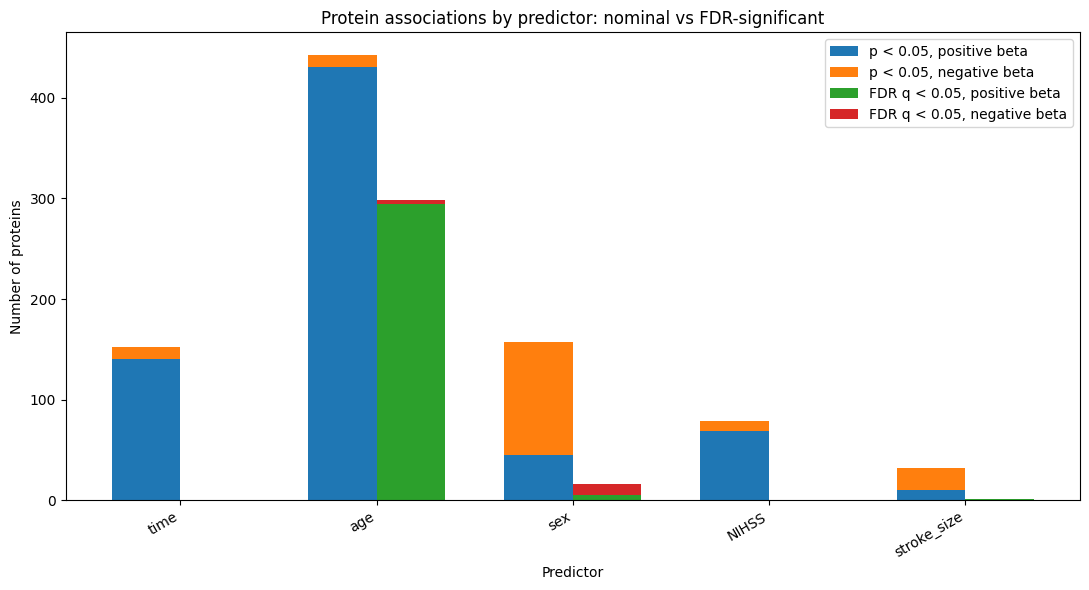

In [ ]:
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

# left stack: p < 0.05
ax.bar(
    x - width/2,
    plot_df["nominal_pos"],
    width,
    label="p < 0.05, positive beta"
)
ax.bar(
    x - width/2,
    plot_df["nominal_neg"],
    width,
    bottom=plot_df["nominal_pos"],
    label="p < 0.05, negative beta"
)

# right stack: FDR q < 0.05
ax.bar(
    x + width/2,
    plot_df["fdr_pos"],
    width,
    label="FDR q < 0.05, positive beta"
)
ax.bar(
    x + width/2,
    plot_df["fdr_neg"],
    width,
    bottom=plot_df["fdr_pos"],
    label="FDR q < 0.05, negative beta"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["predictor"], rotation=30, ha="right")
ax.set_ylabel("Number of proteins")
ax.set_xlabel("Predictor")
ax.set_title("Protein associations by predictor: nominal vs FDR-significant")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

def find_file(filename):
    for root, dirs, files in os.walk("."):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename}")

# FDR-passing proteins from your adjusted model table
predictor_map = {
    "time": ("time_beta", "time_p", "time_FDR_q"),
    "age": ("age_beta", "age_p", "age_FDR_q"),
    "sex": ("sex_beta", "sex_p", "sex_FDR_q"),
    "NIHSS": ("nihss_beta", "nihss_p", "nihss_FDR_q"),
    "stroke_size": ("stroke_size_beta", "stroke_size_p", "stroke_size_FDR_q"),
}

rows = []

for predictor, (beta_col, p_col, q_:contentReference[oaicite:0]{index=0}_map.items():
    tmp = time_screen_results[time_screen_results[q_col] < 0.05].copy()

    for _, row in tmp.iterrows():
        beta = row[beta_col]

        rows.append({
            "predictor": predictor,
            "protein": row["protein"],
            "beta": beta,
            "p_value": row[p_col],
            "FDR_q": row[q_col],
            "direction": "positive_beta" if beta > 0 else "negative_beta"
        })

fdr_proteins = pd.DataFrame(rows)

print("FDR-significant predictor-protein associations:", fdr_proteins.shape[0])
print("Unique FDR-significant proteins:", fdr_proteins["protein"].nunique())

display(fdr_proteins.head())

SyntaxError: invalid syntax (3994975434.py, line 22)

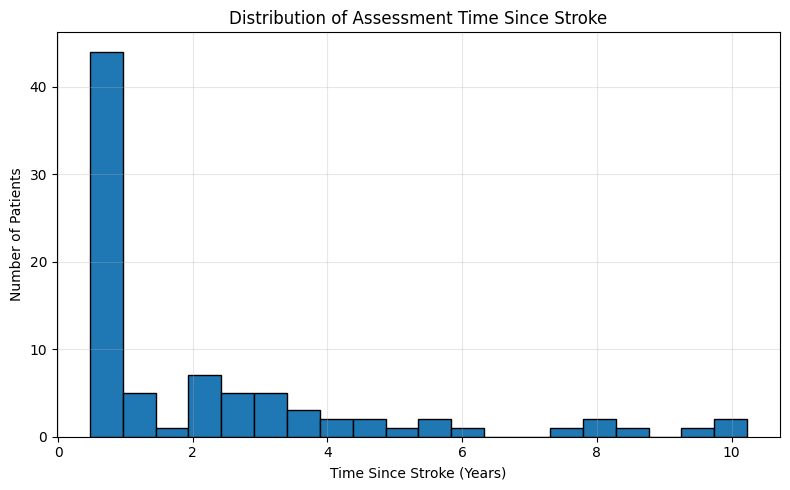

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_patient_data.csv")

years = df["timesince"] / 365.25

plt.figure(figsize=(8,5))

plt.hist(
    years,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Time Since Stroke (Years)")
plt.ylabel("Number of Patients")
plt.title("Distribution of Assessment Time Since Stroke")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

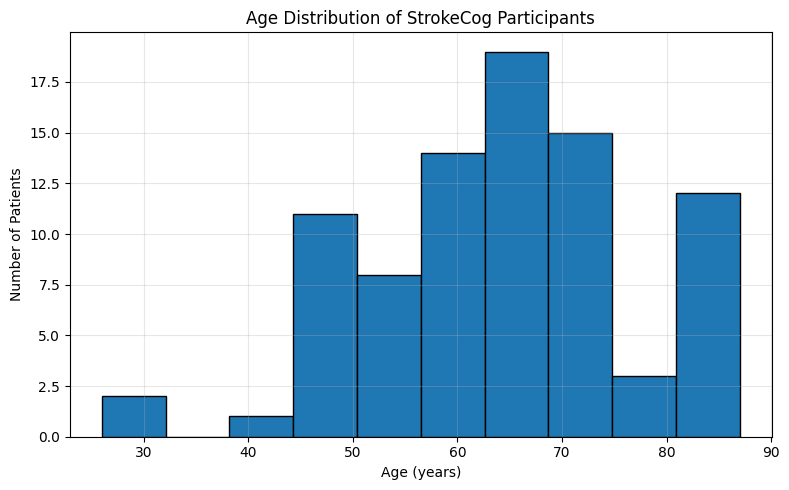

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_patient_data.csv")

plt.figure(figsize=(8,5))

plt.hist(
    df["age"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of StrokeCog Participants")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

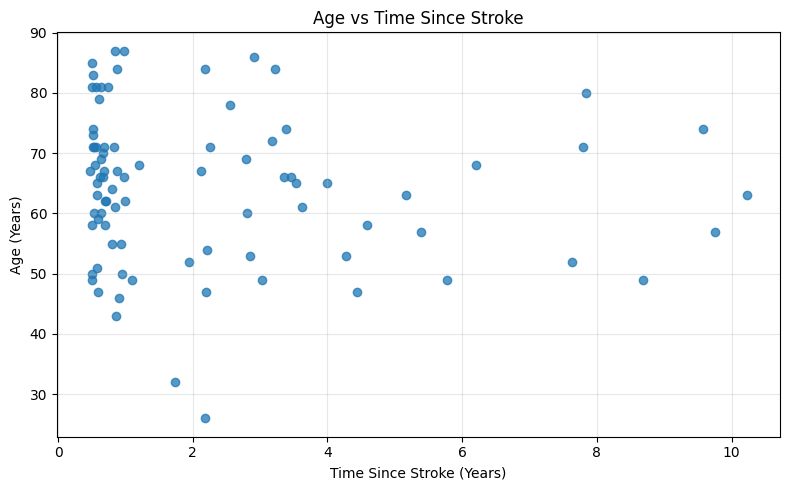

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_patient_data.csv")

df["timesince_years"] = df["timesince"] / 365.25

plt.figure(figsize=(8,5))

plt.scatter(
    df["timesince_years"],
    df["age"],
    alpha=0.75
)

plt.xlabel("Time Since Stroke (Years)")
plt.ylabel("Age (Years)")
plt.title("Age vs Time Since Stroke")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

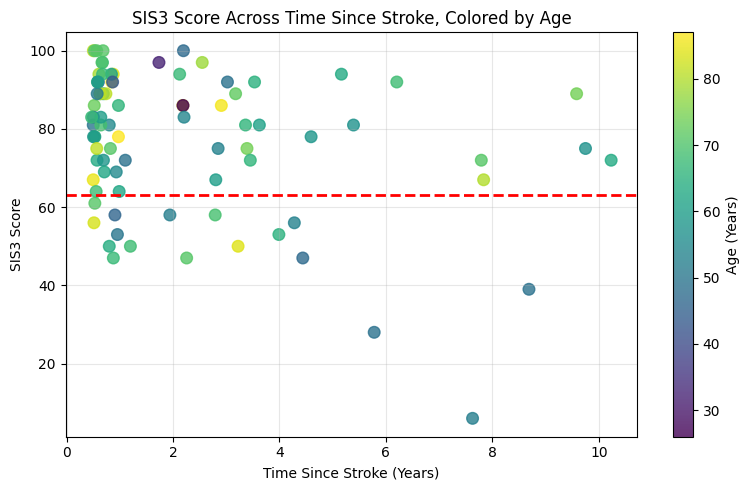

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_patient_data.csv")

df["timesince_years"] = df["timesince"] / 365.25

plot_df = df[["timesince_years", "sis3", "age"]].dropna()

plt.figure(figsize=(8, 5))

sc = plt.scatter(
    plot_df["timesince_years"],
    plot_df["sis3"],
    c=plot_df["age"],
    s=70,
    alpha=0.8
)

plt.axhline(
    y=63,
    color="red",
    linestyle="--",
    linewidth=2,
    label="SIS3 = 63"
)

plt.colorbar(sc, label="Age (Years)")

plt.xlabel("Time Since Stroke (Years)")
plt.ylabel("SIS3 Score")
plt.title("SIS3 Score Across Time Since Stroke, Colored by Age")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



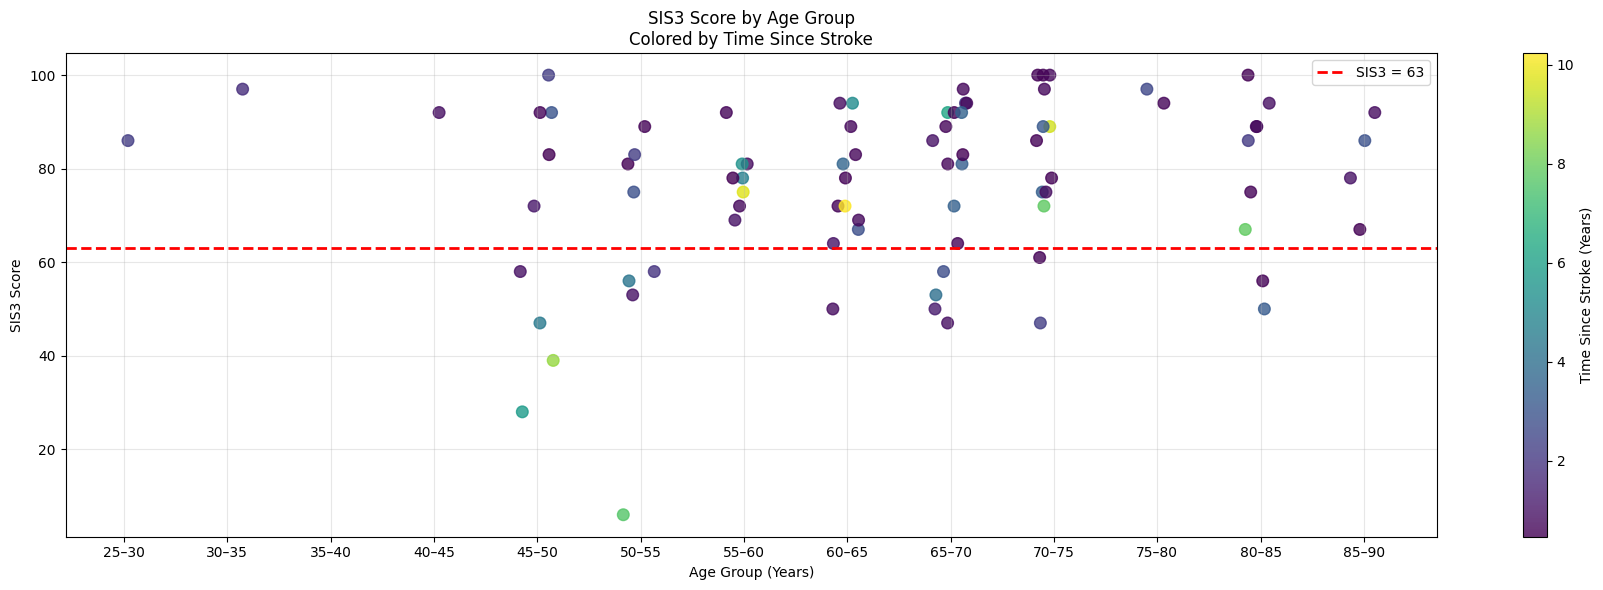


Box 1: young + high SIS3


,pid,age,timesince_years,sis3
12,19,32.0,1.735797,97.0



Box 2: old + high SIS3


,pid,age,timesince_years,sis3
39,53,81.0,0.503765,100.0
10,16,87.0,0.848734,92.0
28,41,84.0,0.876112,94.0



Box 3: low SIS3 outlier


,pid,age,timesince_years,sis3
25,38,52.0,7.627652,6.0



Box 1: young + high SIS3
N = 1
[19]

Box 2: old + high SIS3
N = 3
[16, 41, 53]

Box 3: low SIS3 outlier
N = 1
[38]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_patient_data.csv")

plot_df = df[["pid", "age", "sis3", "timesince"]].dropna().copy()

plot_df["timesince_years"] = plot_df["timesince"] / 365.25

bins = np.arange(25, 95, 5)

labels = [
    f"{bins[i]}–{bins[i+1]}"
    for i in range(len(bins)-1)
]

plot_df["age_bin"] = pd.cut(
    plot_df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

plot_df["bin_number"] = plot_df["age_bin"].cat.codes
plot_df = plot_df[plot_df["bin_number"] >= 0].copy()

jitter = np.random.uniform(-0.18, 0.18, len(plot_df))

plt.figure(figsize=(18,6))

sc = plt.scatter(
    plot_df["bin_number"] + jitter,
    plot_df["sis3"],
    c=plot_df["timesince_years"],
    cmap="viridis",
    s=70,
    alpha=0.8
)

plt.axhline(
    y=63,
    color="red",
    linestyle="--",
    linewidth=2,
    label="SIS3 = 63"
)

cbar = plt.colorbar(sc)
cbar.set_label("Time Since Stroke (Years)")

plt.xticks(
    ticks=range(len(labels)),
    labels=labels
)

plt.xlabel("Age Group (Years)")
plt.ylabel("SIS3 Score")
plt.title("SIS3 Score by Age Group\nColored by Time Since Stroke")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

boxes = {
    "Box 1: young + high SIS3": (
        (plot_df["age"] >= 25) &
        (plot_df["age"] <= 35) &
        (plot_df["sis3"] >= 90)
    ),

    "Box 2: old + high SIS3": (
        (plot_df["age"] >= 80) &
        (plot_df["age"] <= 90) &
        (plot_df["sis3"] >= 90)
    ),

    "Box 3: low SIS3 outlier": (
        plot_df["sis3"] <= 20
    )
}

for box_name, condition in boxes.items():
    print("\n" + box_name)

    display(
        plot_df.loc[condition, [
            "pid",
            "age",
            "timesince_years",
            "sis3"
        ]].sort_values("timesince_years")
    )

for box_name, condition in boxes.items():
    print(f"\n{box_name}")
    print("N =", condition.sum())
    print(plot_df.loc[condition, "pid"].tolist())

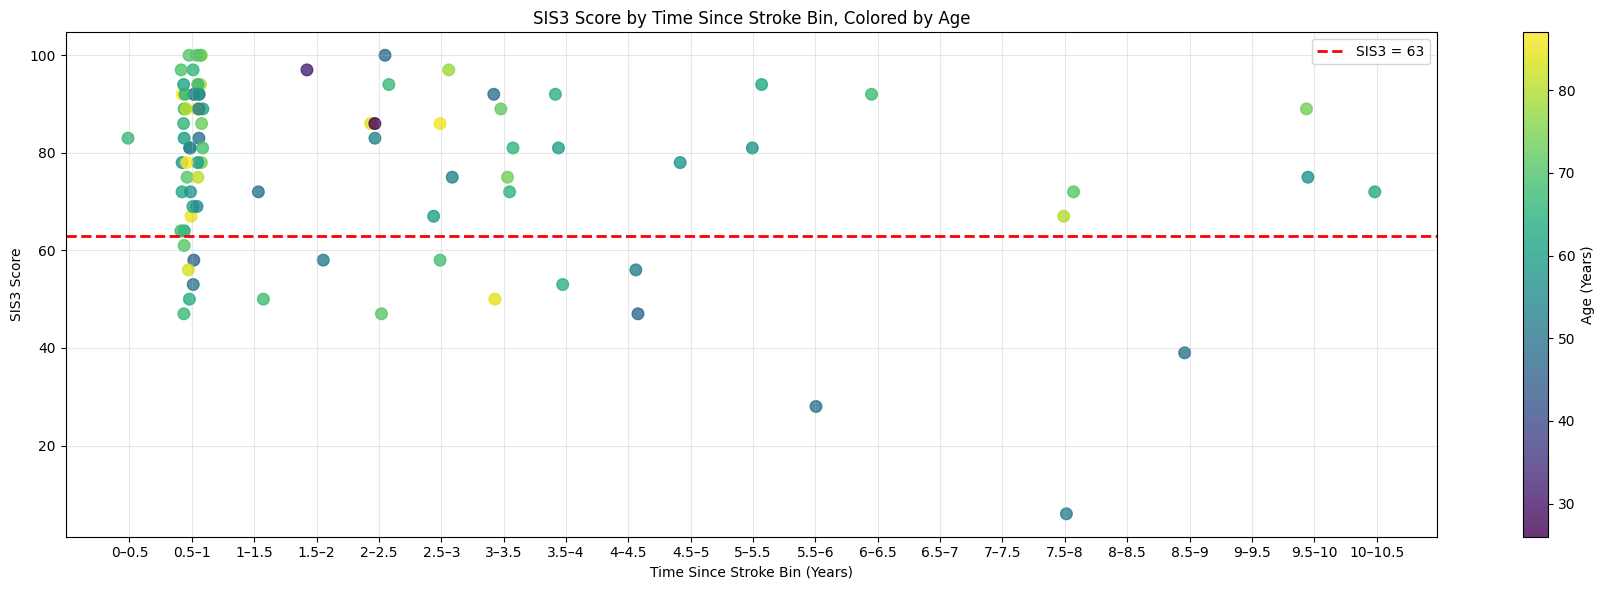


Box 1: early time + low SIS3


,pid,age,timesince_years,sis3
68,100,64.0,0.802190,50.0
46,61,67.0,0.878850,47.0
26,39,68.0,1.199179,50.0
8,14,71.0,2.255989,47.0



Box 2: later time + high SIS3


,pid,age,timesince_years,sis3
15,23,63.0,5.163587,94.0
5,10,68.0,6.203970,92.0



Box 1: early time + low SIS3
N = 4
[14, 39, 61, 100]

Box 2: later time + high SIS3
N = 2
[10, 23]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_patient_data.csv")

plot_df = df[["pid", "age", "sis3", "timesince"]].dropna().copy()

plot_df["timesince_years"] = plot_df["timesince"] / 365.25

max_year = plot_df["timesince_years"].max()

bins = np.arange(0, np.ceil(max_year * 2) / 2 + 0.5, 0.5)

labels = [
    f"{bins[i]:g}–{bins[i+1]:g}"
    for i in range(len(bins) - 1)
]

plot_df["time_bin"] = pd.cut(
    plot_df["timesince_years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plot_df["bin_number"] = plot_df["time_bin"].cat.codes
plot_df = plot_df[plot_df["bin_number"] >= 0].copy()

jitter = np.random.uniform(-0.18, 0.18, len(plot_df))

plt.figure(figsize=(18,6))

sc = plt.scatter(
    plot_df["bin_number"] + jitter,
    plot_df["sis3"],
    c=plot_df["age"],
    cmap="viridis",
    s=70,
    alpha=0.8
)

plt.axhline(
    y=63,
    color="red",
    linestyle="--",
    linewidth=2,
    label="SIS3 = 63"
)

cbar = plt.colorbar(sc)
cbar.set_label("Age (Years)")

plt.xticks(
    ticks=range(len(labels)),
    labels=labels
)

plt.xlabel("Time Since Stroke Bin (Years)")
plt.ylabel("SIS3 Score")
plt.title("SIS3 Score by Time Since Stroke Bin, Colored by Age")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

boxes = {
    "Box 1: early time + low SIS3": (
        (plot_df["timesince_years"] >= 0) &
        (plot_df["timesince_years"] <= 2.5) &
        (plot_df["sis3"] <= 50)
    ),

    "Box 2: later time + high SIS3": (
        (plot_df["timesince_years"] >= 5.0) &
        (plot_df["timesince_years"] <= 10.5) &
        (plot_df["sis3"] >= 90)
    )
}

for box_name, condition in boxes.items():
    print("\n" + box_name)
    display(
        plot_df.loc[condition, [
            "pid", "age", "timesince_years", "sis3"
        ]].sort_values("timesince_years")
    )

for box_name, condition in boxes.items():
    print(f"\n{box_name}")
    print("N =", condition.sum())
    print(plot_df.loc[condition, "pid"].tolist())

    pid      group  zscore_sum  positive_protein_count  negative_protein_count
0    19  High SIS3 -286.913140                     459                     737
1    16  High SIS3  537.431763                     849                     347
2    41  High SIS3  418.601838                     775                     421
3    53  High SIS3 -263.447799                     457                     739
4    10  High SIS3 -179.856357                     450                     746
5    23  High SIS3  -87.363044                     529                     667
6    14   Low SIS3  293.774581                     697                     499
7    39   Low SIS3   82.766833                     587                     609
8    61   Low SIS3  680.440140                     865                     331
9   100   Low SIS3 -527.372938                     300                     896
10   38   Low SIS3  303.744593                     728                     376


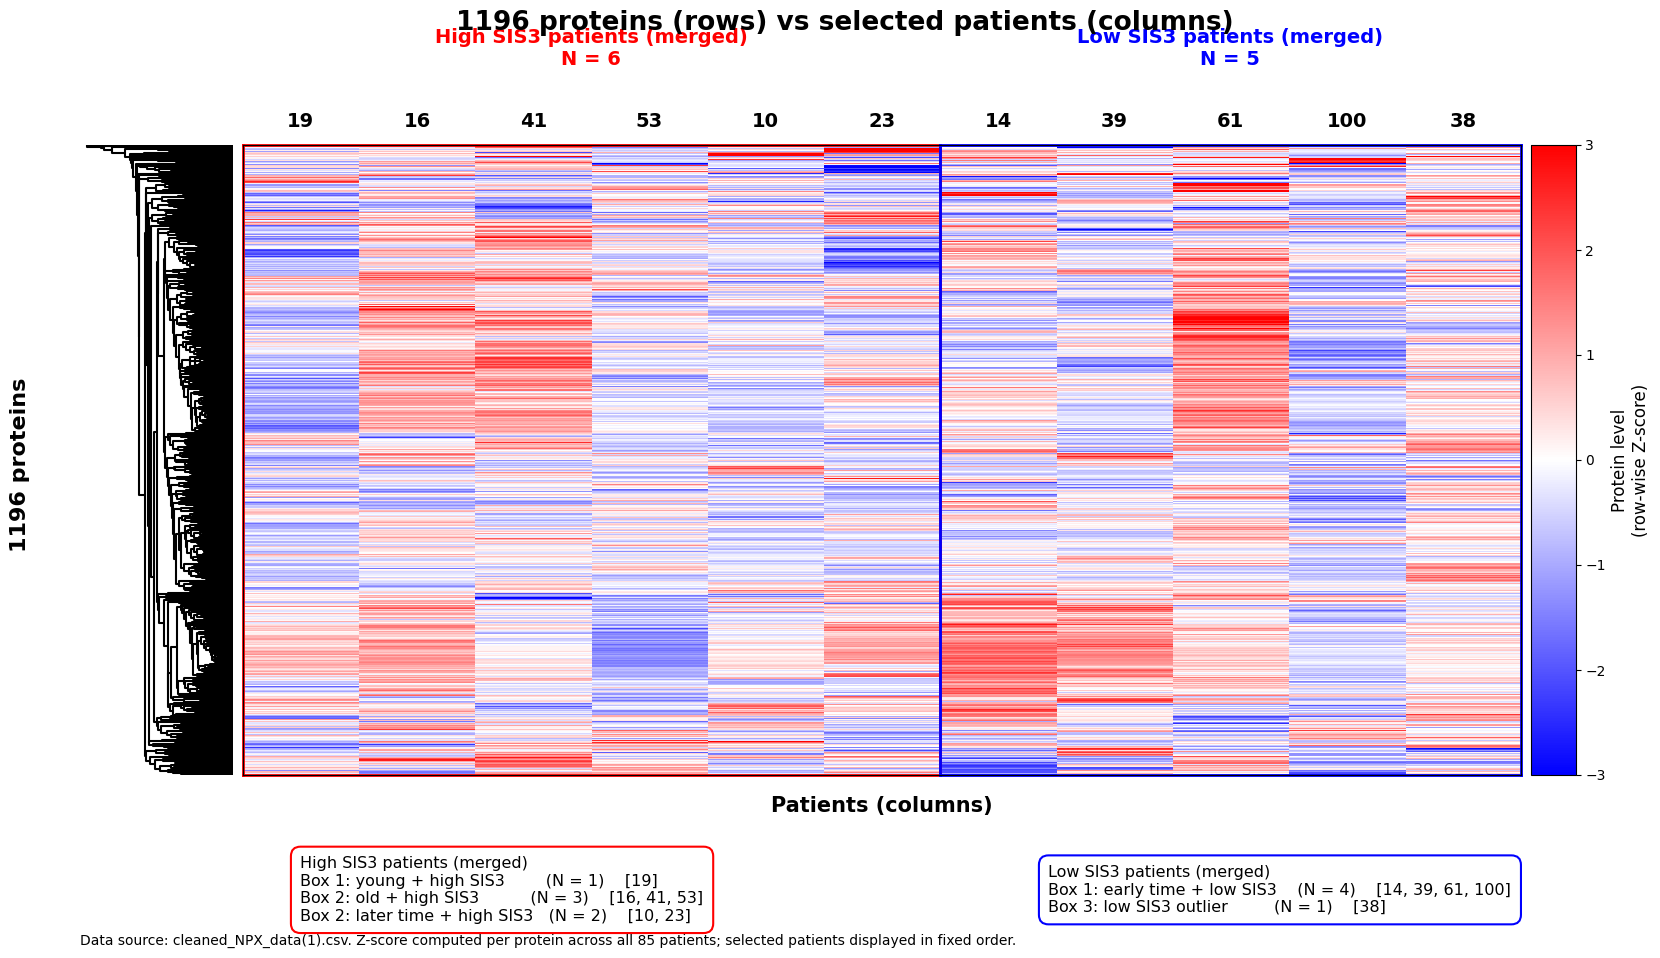

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# =========================
# 1. Load actual NPX data
# =========================
npx = pd.read_csv("cleaned_NPX_data.csv")

# Correct patient groups
high_pids = [19, 16, 41, 53, 10, 23]
low_pids  = [14, 39, 61, 100, 38]
selected_pids = high_pids + low_pids

# Protein columns
protein_cols = [c for c in npx.columns if c != "pid"]

# =========================
# 2. Z-score each protein across all patients
# =========================
protein_mean = npx[protein_cols].mean(axis=0)
protein_std = npx[protein_cols].std(axis=0)

z_npx = (npx[protein_cols] - protein_mean) / protein_std
z_npx["pid"] = npx["pid"].astype(int)

# Matrix: rows = proteins, columns = selected patients
heatmap_data = (
    z_npx.set_index("pid")
    .loc[selected_pids, protein_cols]
    .T
    .fillna(0)
)

# =========================
# 3. Cluster proteins only
# =========================
row_linkage = linkage(
    pdist(heatmap_data.values, metric="euclidean"),
    method="average"
)

dendro = dendrogram(row_linkage, no_plot=True)
row_order = dendro["leaves"]
heatmap_plot = heatmap_data.iloc[row_order, :]

# =========================
# 4. Patient-level Z-score summary
# =========================
summary = pd.DataFrame({
    "pid": selected_pids,
    "group": ["High SIS3"] * len(high_pids) + ["Low SIS3"] * len(low_pids),
    "zscore_sum": heatmap_data.sum(axis=0).reindex(selected_pids).values,
    "positive_protein_count": (heatmap_data > 0).sum(axis=0).reindex(selected_pids).values,
    "negative_protein_count": (heatmap_data < 0).sum(axis=0).reindex(selected_pids).values
})

summary.to_csv("actual_zscore_sum_positive_negative_counts_corrected.csv", index=False)
print(summary)

# =========================
# 5. Plot heatmap
# =========================
fig = plt.figure(figsize=(17, 10))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1.2, 10, 0.35],
    left=0.05,
    right=0.93,
    top=0.82,
    bottom=0.19,
    wspace=0.02
)

ax_d = fig.add_subplot(gs[0, 0])
ax_h = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])

# Dendrogram
dendrogram(
    row_linkage,
    orientation="left",
    no_labels=True,
    color_threshold=0,
    above_threshold_color="black",
    ax=ax_d
)
ax_d.invert_yaxis()
ax_d.axis("off")

# Heatmap
im = ax_h.imshow(
    heatmap_plot.values,
    aspect="auto",
    interpolation="nearest",
    cmap="bwr",
    vmin=-3,
    vmax=3
)

# X-axis patient labels
ax_h.set_xticks(np.arange(len(selected_pids)))
ax_h.set_xticklabels([str(p) for p in selected_pids], fontsize=14, fontweight="bold")
ax_h.xaxis.tick_top()
ax_h.tick_params(axis="x", length=0, pad=10)
ax_h.set_yticks([])
ax_h.set_xlabel("Patients (columns)", fontsize=15, fontweight="bold", labelpad=15)

# Divider between groups
ax_h.axvline(len(high_pids) - 0.5, color="black", linewidth=2)

# Group borders
# High SIS3 box
ax_h.plot([-0.5, len(high_pids)-0.5], [-0.5, -0.5], color="red", lw=2, clip_on=False)
ax_h.plot([-0.5, len(high_pids)-0.5], [heatmap_plot.shape[0]-0.5, heatmap_plot.shape[0]-0.5], color="red", lw=2, clip_on=False)
ax_h.plot([-0.5, -0.5], [-0.5, heatmap_plot.shape[0]-0.5], color="red", lw=2, clip_on=False)
ax_h.plot([len(high_pids)-0.5, len(high_pids)-0.5], [-0.5, heatmap_plot.shape[0]-0.5], color="red", lw=2, clip_on=False)

# Low SIS3 box
ax_h.plot([len(high_pids)-0.5, len(selected_pids)-0.5], [-0.5, -0.5], color="blue", lw=2, clip_on=False)
ax_h.plot([len(high_pids)-0.5, len(selected_pids)-0.5], [heatmap_plot.shape[0]-0.5, heatmap_plot.shape[0]-0.5], color="blue", lw=2, clip_on=False)
ax_h.plot([len(high_pids)-0.5, len(high_pids)-0.5], [-0.5, heatmap_plot.shape[0]-0.5], color="blue", lw=2, clip_on=False)
ax_h.plot([len(selected_pids)-0.5, len(selected_pids)-0.5], [-0.5, heatmap_plot.shape[0]-0.5], color="blue", lw=2, clip_on=False)

# Colorbar
cbar = fig.colorbar(im, cax=ax_c)
cbar.set_label("Protein level\n(row-wise Z-score)", fontsize=12)
cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])

# Main title
fig.suptitle(
    f"{len(protein_cols)} proteins (rows) vs selected patients (columns)",
    fontsize=19,
    fontweight="bold",
    y=0.955
)

# Group titles
ax_h.text(
    2.5, -145,
    "High SIS3 patients (merged)\nN = 6",
    color="red",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)

ax_h.text(
    8.0, -145,
    "Low SIS3 patients (merged)\nN = 5",
    color="blue",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)

# Y-axis label
fig.text(
    0.015, 0.50,
    f"{len(protein_cols)} proteins",
    rotation=90,
    va="center",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

# Bottom group explanation
high_text = (
    "High SIS3 patients (merged)\n"
    "Box 1: young + high SIS3        (N = 1)    [19]\n"
    "Box 2: old + high SIS3          (N = 3)    [16, 41, 53]\n"
    "Box 2: later time + high SIS3   (N = 2)    [10, 23]"
)

low_text = (
    "Low SIS3 patients (merged)\n"
    "Box 1: early time + low SIS3    (N = 4)    [14, 39, 61, 100]\n"
    "Box 3: low SIS3 outlier         (N = 1)    [38]"
)

fig.text(
    0.18, 0.075,
    high_text,
    fontsize=11.5,
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="red", lw=1.5)
)

fig.text(
    0.62, 0.075,
    low_text,
    fontsize=11.5,
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="blue", lw=1.5)
)

fig.text(
    0.05, 0.02,
    "Data source: cleaned_NPX_data(1).csv. Z-score computed per protein across all 85 patients; selected patients displayed in fixed order.",
    fontsize=10
)

# Save
plt.savefig("actual_data_heatmap_high_vs_low_SIS3_corrected_pid38.png", dpi=300, bbox_inches="tight")
plt.savefig("actual_data_heatmap_high_vs_low_SIS3_corrected_pid38.pdf", bbox_inches="tight")

plt.show()